<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br><br><br>

# Listed Volatility and Variance Derivatives

**Wiley Finance (2017)**

Dr. Yves J. Hilpisch | The Python Quants GmbH

http://tpq.io | [@dyjh](http://twitter.com/dyjh) | http://books.tpq.io

<img src="https://hilpisch.com/images/lvvd_cover.png" alt="Listed Volatility and Variance Derivatives" width="30%" align="left" border="0">

# Introduction to Python

Python has become a powerful programming language and has developed a huge ecosystem of helpful libraries over the last couple of years. This chapter provides a concise overview of Python and two of the major pillars of the the so-called *scientific stack*:

* NumPy (see http://numpy.org)
* pandas (see http://pandas.pydata.org)

NumPy provides performant array operations on numerical data while pandas is specifically designed to handle more complex data analytics operations, e.g. on (financial) times series data.

Such an introductory chapter &mdash; only addressing selected topics relevant to the contents of this book &mdash; can of course not replace a thourough introduction to Python and the libraries covered. However, if you are rather new to Python or programming in general you might get a first overview and a feeling of what Python is all about. If you are already experienced in another language typically used in quantitative finance (e.g. Matlab, R, C++, VBA), you see how typical data structures, programming paradigms and idioms in Python look like.

For a comprehensive overview of Python applied to finance see Hilpisch (2014). Other, more general introductions, to the language with a scientific and data analysis focus are Haenel et al. (2013), Langtangen (2009) and McKinney (2012).

This chapter and the rest of the book is based on Python 2.7 although the majority of the code should be easily transformed to Python 3.5 after some minor modifications.

## Python Basics

This section introduces basic Python data types and structures, control structures and some Python idioms.

### Data Types

It is noteworthy that Python is a *dynamically typed system* which means that types of objects are inferred from their contexts. Let us start with numbers. 

In [1]:
a = 3  # defining an integer object
type(a)

int

In [2]:
a.bit_length()  # number of bits used

2

In [3]:
b = 5.  # defining a float object
type(b)

float

Python can handle arbitrarily large integers which is quite beneficial for number theoretical applications, for instance.

In [4]:
c = 10 ** 100  # googol number
type(c)

int

In [5]:
c # long integer object

10000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000

In [6]:
c.bit_length()  # number of bits used

333

Arithmetic operations on these objects work as expected.

In [7]:
3 / 5  # division

0.6

In [8]:
a * b  # multiplication

15.0

In [9]:
a - b  # difference

-2.0

In [10]:
b + a  # addition

8.0

In [11]:
a ** b  # power

243.0

Many oftenly used mathematical functions are found in the ``math`` module which is part of Python's standard library.

In [12]:
import math  # importing the library into the namespace

In [13]:
math.log(a)  # natural logarithm

1.0986122886681098

In [14]:
math.exp(a)  # exponential function

20.085536923187668

In [15]:
math.sin(b)  # sine function

-0.9589242746631385

Another important basic data type are string objects.

In [16]:
s = 'Listed Volatility and Variance Derivatives.'
type(s)

str

This object type has multiple methods attached.

In [17]:
s.lower()  # converting to lower case characters

'listed volatility and variance derivatives.'

In [18]:
s.upper()  # converting to upper case characters

'LISTED VOLATILITY AND VARIANCE DERIVATIVES.'

Strings objects can be easily sliced. Note that Python has in general zero-based numbering and indexing.

In [19]:
s[0:6]

'Listed'

Such objects can also be combined using the ``+`` operator. The index value -1 represents the last character of a string (or last element of a sequence in general).

In [20]:
st = s[0:6] + s[-13:-1]
print(st)

Listed Derivatives


String replacements are often used to parametrize text output.

In [21]:
repl = "My name is %s, I am %d years old and %4.2f m tall."
## replace %s by a string, %d by an integer and
## %4.2f by a float showing 2 decimal values
print(repl % ('Peter', 35, 1.88)) 

My name is Peter, I am 35 years old and 1.88 m tall.


A different way to reach the same goal is the following.

In [22]:
repl = "My name is {:s}, I am {:d} years old and {:4.2f} m tall."
print(repl.format('Peter', 35, 1.88))

My name is Peter, I am 35 years old and 1.88 m tall.


### Data Structures

A light weight data structure are tuples. These are immutable collections of other objects and are constucted by objects separated by commas &mdash; with or without parentheses. 

In [23]:
t1 = (a, b, st)
t1

(3, 5.0, 'Listed Derivatives')

In [24]:
type(t1)

tuple

In [25]:
t2 = st, b, a
t2

('Listed Derivatives', 5.0, 3)

In [26]:
type(t2)

tuple

Nested structures are also possible. 

In [27]:
t = (t1, t2)

In [28]:
t

((3, 5.0, 'Listed Derivatives'), ('Listed Derivatives', 5.0, 3))

In [29]:
t[0][2]  # take 3rd element of 1st element

'Listed Derivatives'

List objects are mutable collections of other objects and are generally constructed by providing a comma separated collection of objects in brackets.

In [30]:
l = [a, b, st]
l

[3, 5.0, 'Listed Derivatives']

In [31]:
type(l)

list

In [32]:
l.append(s.split()[3])  # append 4th word of string
l

[3, 5.0, 'Listed Derivatives', 'Variance']

Sorting is a typical operation on list objects which can also be constructed using the ``list`` constructor (here applied to a tuple object).

In [33]:
l = list(('Z', 'Q', 'D', 'J', 'E', 'H'))
l

['Z', 'Q', 'D', 'J', 'E', 'H']

In [34]:
l.sort()  # in-place sorting
l

['D', 'E', 'H', 'J', 'Q', 'Z']

Dictionary objects are so-called key-value stores and are generally constructed with curley brackets.

In [35]:
d = {'int_obj': a,
    'float_obj': b,
    'string_obj': st}
type(d)

dict

In [36]:
d

{'int_obj': 3, 'float_obj': 5.0, 'string_obj': 'Listed Derivatives'}

In [37]:
d['float_obj']  # look-up of value given key

5.0

In [38]:
d['long_obj'] = c / 10 ** 90  # adding new key value pair
d

{'int_obj': 3,
 'float_obj': 5.0,
 'string_obj': 'Listed Derivatives',
 'long_obj': 10000000000.0}

Keys and values of a dictionary object can be retrieved as list objects.

In [39]:
d.keys()

dict_keys(['int_obj', 'float_obj', 'string_obj', 'long_obj'])

In [40]:
d.values()

dict_values([3, 5.0, 'Listed Derivatives', 10000000000.0])

### Control Structures

Iterations are very important operations in programming in general and financial analytics in particular. Many Python objects are iterable which proves rather convenient in many circumstances. Consider the special list object constructor ``range``.

In [41]:
range(5)  # all integers from zero to 5 excluded

range(0, 5)

In [42]:
range(3, 15, 2)  # start at 3, step with 2 until 15 excluded

range(3, 15, 2)

Such a list object constructor is often used in the context of a ``for`` loop.

In [43]:
for i in range(5):
    print(i ** 2, end=' ')

0 1 4 9 16 

However, you can iterate over any sequence.

In [44]:
## iteration over list object
for _ in l:
    print(_, end=' ')

D E H J Q Z 

In [45]:
## iteration over string object
for c in st:
    print(c + '|', end=' ')

L| i| s| t| e| d|  | D| e| r| i| v| a| t| i| v| e| s| 

``while`` loops are similar to their counterparts in other languages.

In [46]:
i = 0  # initialize counter
while i < 5:
    print(i ** 0.5, end=' ')  # output
    i += 1  # increase counter by 1

0.0 1.0 1.4142135623730951 1.7320508075688772 2.0 

The ``if-elif-else`` control structure is introduced below in the context of Python function definitions.

### Special Python Idioms 

Python in many places relies on a number of special idioms. Let us start with a rather popular one, the list comprehension.

In [47]:
lc = [i ** 2 for i in range(10)]
lc

[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]

As the name suggests, the result is a list object.

In [48]:
type(lc)

list

So-called lambda or anonymous functions are usuful helpers in many places.

In [49]:
f = lambda x: math.cos(x) # returns cos of x
f(5)

0.28366218546322625

List comprehensions can be combined with lambda functions to achieve concise constructions of list objects.

In [50]:
lc = [f(x) for x in range(10)]
lc

[1.0,
 0.5403023058681398,
 -0.4161468365471424,
 -0.9899924966004454,
 -0.6536436208636119,
 0.28366218546322625,
 0.960170286650366,
 0.7539022543433046,
 -0.14550003380861354,
 -0.9111302618846769]

However, there is an even more concise way of constructing the same list object &mdash; using functional programming approaches, in the case to follow with ``map``.

In [51]:
list(map(lambda x: math.cos(x), range(10)))

[1.0,
 0.5403023058681398,
 -0.4161468365471424,
 -0.9899924966004454,
 -0.6536436208636119,
 0.28366218546322625,
 0.960170286650366,
 0.7539022543433046,
 -0.14550003380861354,
 -0.9111302618846769]

In general, one works with regular Python functions (as opposed to lambda functions) which are constructed as follows.

In [52]:
def f(x):
    return math.exp(x)
f(5)

148.4131591025766

The general construction looks like this.

In [53]:
def f(*args):  # multiple arguments
    for arg in args:
        print(arg)
        # do something with arguments
    return None  # return result(s) (not necessary)

f(l)

['D', 'E', 'H', 'J', 'Q', 'Z']


Consider the following function definition which returns different values/strings based on an ``if-elif-else`` control structure.

In [54]:
import random  # import random number library
a = random.randint(0, 1000)  # draw random number between 0 and 1000
print("Random number is %d" % a)
def number_decide(number):
    if a < 10:
        return "Number is single digit."
    elif 10 <= a < 100:
        return "Number is double digit."
    else:
        return "Number is triple digit."
number_decide(a)

Random number is 280


'Number is triple digit.'

A specialty of Python are generator objects. One constructor for such objects that is commonly used is ``xrange``. 

In [55]:
g = range(10)
type(g)  # object type

range

In [56]:
g  # object instance

range(0, 10)

In [57]:
for _ in g:
    print(_, end=' ')  # integers are "generated" when needed

0 1 2 3 4 5 6 7 8 9 

Generator objects can in many scenarios replace (typical) list objects and have the major advantage that they are in general much more memory efficient. Consider a financial algorithm that requires 10 mn loops. Iterating over a list of integers from 0 to 9,999,999 is not efficient since the algorithm (in general) does not need to have all these numbers available at the same time. But this is what happens when using ``range`` for such a loop.

Consider the following construction of the respective list object containing all integers.

In [58]:
%time r = list(range(10000000))

CPU times: user 54.3 ms, sys: 20.5 ms, total: 74.9 ms
Wall time: 80.2 ms


This object consumes 80 MB (!) of RAM (10 mn times 8 bytes).

In [59]:
import sys
sys.getsizeof(r)  # size in bytes of object

80000056

On the other hand, consider the analogous construction based on a generator (``range``) object. It is much, much faster since no memory has to be allocated, no list object has to be generated up-front, etc.

In [60]:
%time xr = range(10000000)

CPU times: user 1e+03 ns, sys: 0 ns, total: 1e+03 ns
Wall time: 2.15 μs


Memory consumption is also much, much more efficient &mdash; 40 bytes compared to 80 MB.

In [61]:
sys.getsizeof(xr)

48

However, in practical applications the two can be used often interchangeably such that one should always resort to the more efficient alternative when possible. The following examples calculate &mdash; using the functional programming operation ``reduce`` &mdash; the sum of all integers from 0 to 9,999,999. Although in this case there is hardly a performance difference, the first operation requires 80 MB of memory while the second might only require less than 100 bytes.

In [62]:
from functools import reduce

In [63]:
%time reduce(lambda x, y: x + y, list(range(1000000)))

CPU times: user 39.8 ms, sys: 5.15 ms, total: 44.9 ms
Wall time: 44.9 ms


499999500000

In [64]:
%time reduce(lambda x, y: x + y, range(1000000))

CPU times: user 35.7 ms, sys: 238 μs, total: 36 ms
Wall time: 35.9 ms


499999500000

More Pythonic (and faster in general) is to calculate the sum using the built-in ``sum`` function &mdash; in this case a significant performance advantage for the generator approach emerges.

In [65]:
%timeit sum(list(range(1000000)))

12.6 ms ± 376 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [66]:
%timeit sum(range(1000000))

7.13 ms ± 94.6 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


There is also a way of indirectly constructing a generator object, i.e. by the use of parentheses. The following code results in a generator object for the sine values of the numbers from 0 to 99.

In [67]:
g = (math.sin(x) for x in range(100))
g

<generator object <genexpr> at 0x107b5e670>

Yet another way of constructing a generator object is by a definition style that resembles the  standard function definition closely. The difference is that instead of the ``return`` statement, the ``yield`` statement is used.

In [68]:
def g(start, end):
    while start <= end:
        yield start  # yield "next" value
        start += 1  # increase by one

Usage then might be as follows.

In [69]:
go = g(15, 20)
for _ in go:
    print(_, end=' ')

15 16 17 18 19 20 

## NumPy

Many operations in computational finance take place over (large) arrays of numerical data. NumPy is a Python  library that allows the efficient handling of and operation on such data structures. Although quite a mighty library with a wealth of functionality, it suffices for the purposes of this book to cover the basics of NumPy.

In [1]:
import numpy as np

The workhorse is the NumPy ``ndarray`` class which provides the data structure for n-dimensional, immutable array objects. You can generate an ``ndarray`` object e.g. out of a list object.

In [2]:
a = np.array(range(24))
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

The power of these objects lies in the management of n-dimensional data structures (e.g. matrices or cubes of data).

In [3]:
b = a.reshape((4, 6))
b

array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11],
       [12, 13, 14, 15, 16, 17],
       [18, 19, 20, 21, 22, 23]])

In [4]:
c = a.reshape((2, 3, 4))
c

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

So-called *standard arrays* (in contrast to e.g. structured arrays) have a single ``dtype`` (i.e. NumPy data type). Consider the following operation which changes the ``dtype`` parameter of the ``b`` object to float.

In [5]:
b = np.array(b, dtype=float)
b

array([[ 0.,  1.,  2.,  3.,  4.,  5.],
       [ 6.,  7.,  8.,  9., 10., 11.],
       [12., 13., 14., 15., 16., 17.],
       [18., 19., 20., 21., 22., 23.]])

A major strength of NumPy are *vectorized operations*.

In [6]:
2 * b

array([[ 0.,  2.,  4.,  6.,  8., 10.],
       [12., 14., 16., 18., 20., 22.],
       [24., 26., 28., 30., 32., 34.],
       [36., 38., 40., 42., 44., 46.]])

In [7]:
b ** 2

array([[  0.,   1.,   4.,   9.,  16.,  25.],
       [ 36.,  49.,  64.,  81., 100., 121.],
       [144., 169., 196., 225., 256., 289.],
       [324., 361., 400., 441., 484., 529.]])

You can also pass ``ndarray`` objects to lambda or standard Python functions.

In [8]:
f = lambda x: x ** 2 - 2 * x + 0.5
f(a)

array([  0.5,  -0.5,   0.5,   3.5,   8.5,  15.5,  24.5,  35.5,  48.5,
        63.5,  80.5,  99.5, 120.5, 143.5, 168.5, 195.5, 224.5, 255.5,
       288.5, 323.5, 360.5, 399.5, 440.5, 483.5])

In many scenarios, only a (small) part of the data stored in a ``ndarray`` object is of interest. NumPy supports basic and advanced slicing and other selection features.

In [9]:
a[2:6]  # 3rd to 6th element

array([2, 3, 4, 5])

In [10]:
b[2, 4]  # 3rd row, final (5th)

16.0

In [11]:
b[1:3, 2:4]  # middle square of numbers

array([[ 8.,  9.],
       [14., 15.]])

Boolean operations are also supported in many places.

In [12]:
## which numbers are larger than 10?
b > 10

array([[False, False, False, False, False, False],
       [False, False, False, False, False,  True],
       [ True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True]])

In [13]:
## only those numbers (flat) that are larger than 10
b[b > 10]

array([11., 12., 13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23.])

Furthermore, ``ndarray`` objects have multiple (convenience) methods already built in.

In [14]:
a.sum()  # sum of all elements

276

In [15]:
b.mean()  # mean of all elements

11.5

In [16]:
b.mean(axis=0)  # mean along 1st axis

array([ 9., 10., 11., 12., 13., 14.])

In [17]:
b.mean(axis=1)  # mean along 2nd axis

array([ 2.5,  8.5, 14.5, 20.5])

In [18]:
c.std()  # standard deviation for all elements

6.922186552431729

Similarly, there is a wealth of so-called *universal functions* that the NumPy library provides. Universal in the sense that they can be applied in general to NumPy ``ndarray`` objects and to standard numerical Python data types.

In [19]:
np.sum(a)  # sum of all elements

276

In [20]:
np.mean(b, axis=0)  # mean alond 1st axis

array([ 9., 10., 11., 12., 13., 14.])

In [21]:
np.sin(b).round(2)  # sine of all elements (rounded)

array([[ 0.  ,  0.84,  0.91,  0.14, -0.76, -0.96],
       [-0.28,  0.66,  0.99,  0.41, -0.54, -1.  ],
       [-0.54,  0.42,  0.99,  0.65, -0.29, -0.96],
       [-0.75,  0.15,  0.91,  0.84, -0.01, -0.85]])

In [22]:
np.sin(4.5)  # sine of Python float object

-0.977530117665097

However, you should be aware that applying NumPy universal functions to standard Python data types generally comes with a significant performance burden.

In [23]:
%time l = [np.sin(x) for x in range(100000)]

CPU times: user 53.8 ms, sys: 2.96 ms, total: 56.7 ms
Wall time: 56.1 ms


In [24]:
import math
%time l = [math.sin(x) for x in range(100000)]

CPU times: user 17.4 ms, sys: 2.72 ms, total: 20.1 ms
Wall time: 19.2 ms


Using the vectorized operations from NumPy is faster than both of the above alternatives which result in list objects.

In [25]:
%time l = np.sin(np.arange(100000))

CPU times: user 2.77 ms, sys: 1.8 ms, total: 4.57 ms
Wall time: 2.93 ms


Here, we use the ndarray object constructor ``arange`` which yields an ``ndarray`` object of integers -- below a simple example.

In [26]:
ai = np.arange(10)
ai

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [27]:
ai.dtype

dtype('int64')

Using this constructor, you can also generate ``ndarray`` objects with different ``dtype`` attributes.

In [28]:
af = np.arange(0.5, 9.5, 0.5)  # start, end, step size
af

array([0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. , 6.5,
       7. , 7.5, 8. , 8.5, 9. ])

In [29]:
af.dtype

dtype('float64')

Useful in this context is also the ``linspace`` operator providing an ``ndarray`` object with evenly spaced numbers.

In [30]:
np.linspace(0, 10, 12)  # start, end, number of elements

array([ 0.        ,  0.90909091,  1.81818182,  2.72727273,  3.63636364,
        4.54545455,  5.45454545,  6.36363636,  7.27272727,  8.18181818,
        9.09090909, 10.        ])

In financial analytics one often needs (pseudo-) random numbers. NumPy provides many functions to sample from different distributions. Those needed in this book are the standard normal distribution and the Poisson distribution. The respective functions are found in the sub-library ``numpy.random``. 

In [31]:
np.random.standard_normal(10) 

array([-0.37808114,  0.37705957, -0.30706031, -2.05771412, -0.73871105,
       -0.82780907,  0.55488769, -1.15156849, -1.43921522, -1.00979897])

In [32]:
np.random.poisson(0.5, 10)

array([0, 0, 1, 0, 1, 0, 0, 0, 0, 2])

Let us generate a ``ndarray`` object which is a bit more "realistic" and with which we work in what follows.

In [33]:
np.random.seed(1000)  # fix the rng seed value
data = np.random.standard_normal((5, 100))

Although this is a slightly larger array one cannot expect that the 500 numbers are indeed standard normally distributed in the sense that the first moment is 0 and the second moment is 1. However, at least this can be easily corrected.

In [34]:
data.mean()  # should be 0.0

-0.02714981205311328

In [35]:
data.std()  # should be 1.0

1.0016799134894265

The correction is called moment matching and can be implemented with NumPy by vectorized operations. 

In [36]:
data = data - data.mean()  # correction for the 1st moment
data = data / data.std()  # correction for the 2nd moment

In [37]:
data.mean()  # now really close to 0.0

-3.552713678800501e-18

In [38]:
data.std()  # now really close to 1.0

1.0

## matplotlib

At this stage, it makes sense to introduce plotting with matplotlib, the plotting work horse in the Python ecosystem. We use matplotlib (see http://matplotlib.org) with the settings of another library throughout, namely seaborn (see http://stanford.edu/~mwaskom/software/seaborn/) &mdash; this results in a more modern plotting style.

In [39]:
import matplotlib.pyplot as plt  # import main plotting library
plt.style.use('seaborn-v0_8')
import matplotlib
## set font to serif
matplotlib.rcParams['font.family'] = 'serif'

A standard plot is the *line plot*. The result of the code below is shown in the following figure.

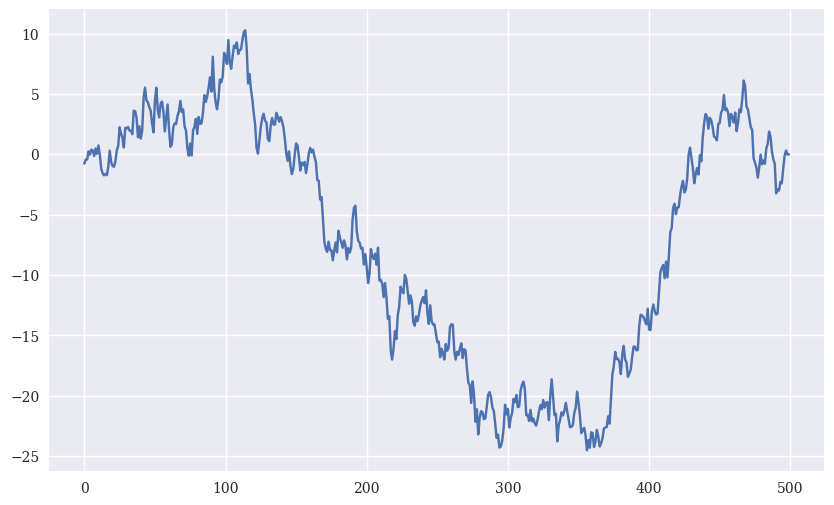

In [40]:
plt.figure(figsize=(10, 6));  # size of figure
plt.plot(data.cumsum());  # cumulative sum over all elements 

<p style="font-family: monospace;">Standard line plot with matplotlib.</p>

Multiple lines plots are also easy to generate (see the following figure). The operator ``T`` stands for the  transpose of the ``ndarray`` object ("matrix").

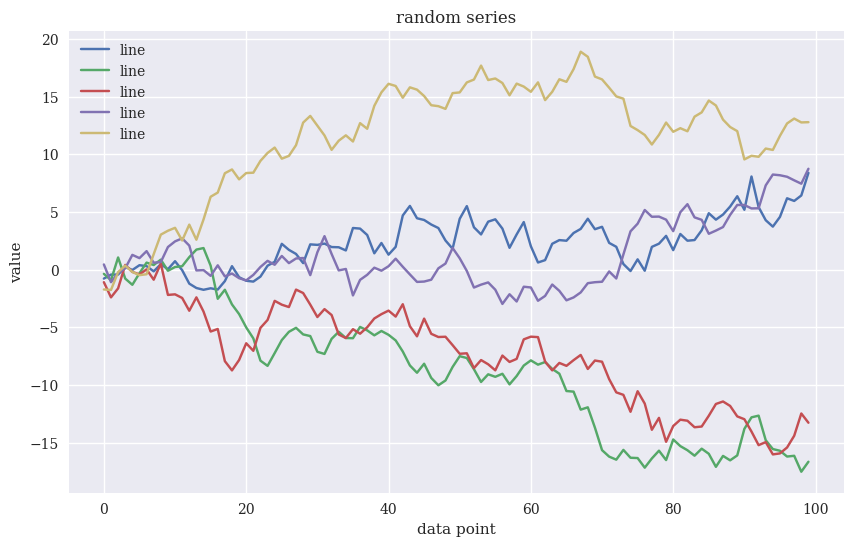

In [41]:
plt.figure(figsize=(10, 6));  # size of figure
## plotting five cumulative sums as lines
plt.plot(data.T.cumsum(axis=0), label='line');
plt.legend(loc=0);  # legend in best location
plt.xlabel('data point');  # x axis label
plt.ylabel('value');  # y axis label
plt.title('random series');  # figure title

<p style="font-family: monospace;">Multiple lines plot with matplotlib.</p>

Other important plotting types are *histograms* and *bar charts*. A histogram for all 500 values of the ``data`` object is shown in the following figure. In the code, the ``flatten()`` method is used to generate a one-dimensional array from the two-dimensional one.

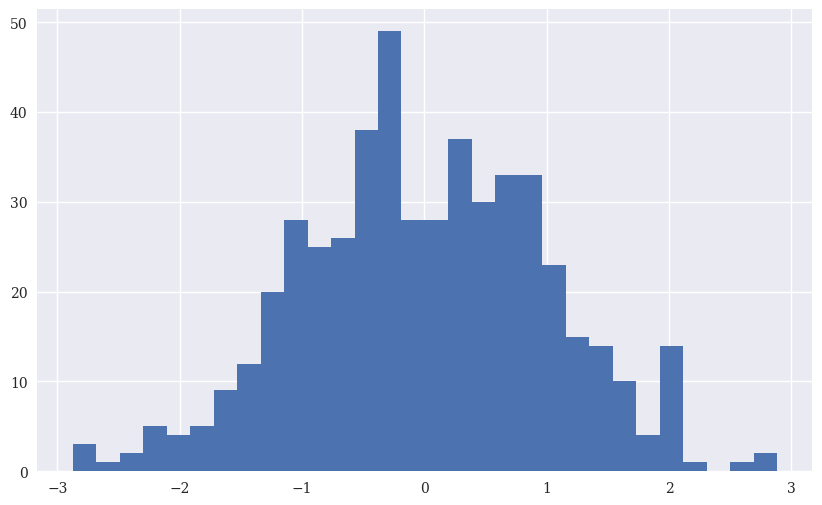

In [42]:
plt.figure(figsize=(10, 6));  # size of figure
plt.hist(data.flatten(), bins=30);

<p style="font-family: monospace;">Histrogram with matplotlib.</p>

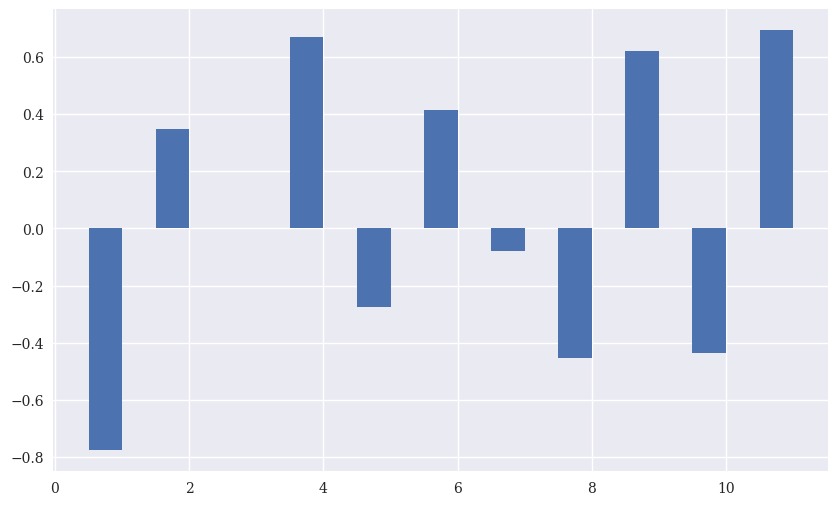

In [43]:
plt.figure(figsize=(10, 6));  # size of figure
plt.bar(np.arange(1, 12) - 0.25, data[0, :11], width=0.5);

<p style="font-family: monospace;">Bar chart with matplotlib.</p>

To conclude the introduction to matplotlib consider the ordinary least squares (OLS) regression of the sample data displayed in the following figure. NumPy provides with the two functions ``polyfit()`` and ``polyval()`` convenience functions to implement OLS based on simple monomials, i.e. $x, x^2, x^3, ..., x^n$. For illustration purposes consider linear, quadratic and cubic OLS.

In [44]:
x = np.arange(len(data.cumsum()))
y = data.cumsum()
rg1 = np.polyfit(x, y, 1)  # linear OLS
rg2 = np.polyfit(x, y, 2)  # quadratic OLS
rg3 = np.polyfit(x, y, 3)  # cubic OLS

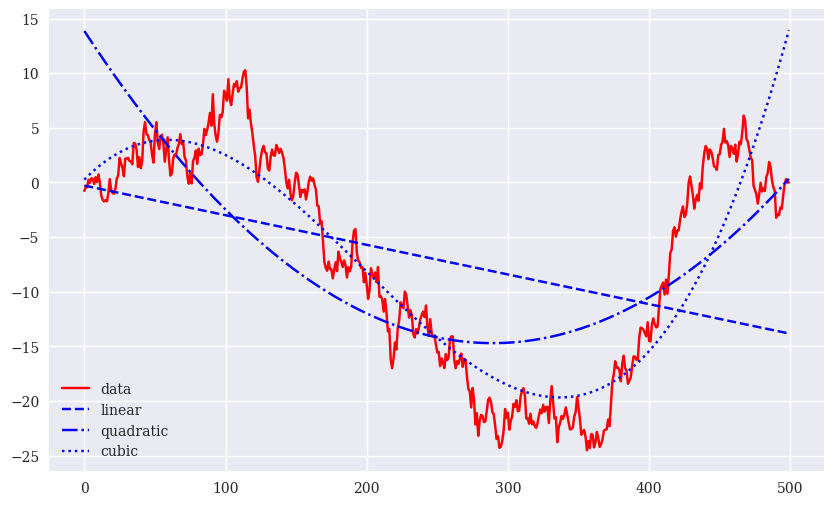

In [45]:
plt.figure(figsize=(10, 6));
plt.plot(x, y, 'r', label='data');
plt.plot(x, np.polyval(rg1, x), 'b--', label='linear');
plt.plot(x, np.polyval(rg2, x), 'b-.', label='quadratic');
plt.plot(x, np.polyval(rg3, x), 'b:', label='cubic');
plt.legend(loc=0);

<p style="font-family: monospace;">Linear, quadratic and cubic regression.

## pandas

pandas is a library with which you can manage and operate on time series data and other tabular data structures. It allows to implement even sophisticated data analytics tasks on larger data sets. While the focus lies on in-memory operations, there are also multiple options for out-of-memory (on-disk) operations. Although pandas provides a number of different data structures, embodied by powerful classes, the most oftenly used structure is the ``DataFrame`` class which resembles a typical table of a relational (SQL) database and is used to manage, for instance, financial time series data. This is what we focus on in this section.

### pandas DataFrame class

In its most basic form, a ``DataFrame`` object is characterized by an index, column names and tabular data. To make this more specific, consider the following sample data set.

In [46]:
np.random.seed(1000)
a = np.random.standard_normal((10, 3)).cumsum(axis=0)

Also, consider the following dates which shall be our index.

In [116]:
index = ['2016-1-31', '2016-2-28', '2016-3-31',
        '2016-4-30', '2016-5-31', '2016-6-30',
        '2016-7-31', '2016-8-31', '2016-9-30',
        '2016-10-31']

Finally, the column names.

In [117]:
columns = ['no1', 'no2', 'no3']

The instantiation of a ``DataFrame`` object then looks as follows.

In [118]:
import pandas as pd
df = pd.DataFrame(a, index=index, columns=columns)

A look at the new object reveals its resemblence with a typical table from a relational database (or e.g. an Excel spreadsheet).

In [119]:
df

,no1,no2,no3
2016-1-31,-0.804458,0.320932,-0.025483
2016-2-28,-0.160134,0.020135,0.363992
2016-3-31,-0.267572,-0.459848,0.959027
2016-4-30,-0.732239,0.207433,0.152912
2016-5-31,-1.928309,-0.198527,-0.029466
2016-6-30,-1.825116,-0.336949,0.676227
2016-7-31,-0.553321,-1.323696,0.341391
2016-8-31,-0.652803,-0.916504,1.260779
2016-9-30,-0.340685,0.616657,0.710605
2016-10-31,-0.723832,-0.206284,2.310688


DataFrame objects have built in a multitude of basic, advanced and convenience methods, a few of which are illustrated without much commentary below.

In [120]:
df.head()  # first five rows

,no1,no2,no3
2016-1-31,-0.804458,0.320932,-0.025483
2016-2-28,-0.160134,0.020135,0.363992
2016-3-31,-0.267572,-0.459848,0.959027
2016-4-30,-0.732239,0.207433,0.152912
2016-5-31,-1.928309,-0.198527,-0.029466


In [121]:
df.tail()  # last five rows

,no1,no2,no3
2016-6-30,-1.825116,-0.336949,0.676227
2016-7-31,-0.553321,-1.323696,0.341391
2016-8-31,-0.652803,-0.916504,1.260779
2016-9-30,-0.340685,0.616657,0.710605
2016-10-31,-0.723832,-0.206284,2.310688


In [122]:
df.index  # index object

Index(['2016-1-31', '2016-2-28', '2016-3-31', '2016-4-30', '2016-5-31',
       '2016-6-30', '2016-7-31', '2016-8-31', '2016-9-30', '2016-10-31'],
      dtype='object')

In [123]:
df.columns  # column names

Index(['no1', 'no2', 'no3'], dtype='object')

In [124]:
df.info()  # meta information

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 2016-1-31 to 2016-10-31
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   no1     10 non-null     float64
 1   no2     10 non-null     float64
 2   no3     10 non-null     float64
dtypes: float64(3)
memory usage: 320.0+ bytes


In [125]:
df.describe()  # typical statistics

,no1,no2,no3
count,10.000000,10.000000,10.000000
mean,-0.798847,-0.227665,0.672067
std,0.607430,0.578071,0.712430
min,-1.928309,-1.323696,-0.029466
25%,-0.786404,-0.429123,0.200031
50%,-0.688317,-0.202406,0.520109
75%,-0.393844,0.160609,0.896922
max,-0.160134,0.616657,2.310688


Numerical operations are in general as easy with ``DataFrame`` objects as with NumPy ``ndarray`` objects. They are also quite close in terms of syntax.

In [126]:
df * 2  # vectorized multiplication

,no1,no2,no3
2016-1-31,-1.608917,0.641863,-0.050966
2016-2-28,-0.320269,0.040270,0.727983
2016-3-31,-0.535144,-0.919696,1.918054
2016-4-30,-1.464479,0.414866,0.305823
2016-5-31,-3.856618,-0.397054,-0.058932
2016-6-30,-3.650232,-0.673898,1.352453
2016-7-31,-1.106642,-2.647393,0.682782
2016-8-31,-1.305605,-1.833009,2.521557
2016-9-30,-0.681369,1.233314,1.421210
2016-10-31,-1.447664,-0.412568,4.621376


In [127]:
df.std()  # standard deviation by column

no1    0.607430
no2    0.578071
no3    0.712430
dtype: float64

In [128]:
df.mean(axis=1)  # mean by index value

2016-1-31    -0.169670
2016-2-28     0.074664
2016-3-31     0.077202
2016-4-30    -0.123965
2016-5-31    -0.718767
2016-6-30    -0.495280
2016-7-31    -0.511875
2016-8-31    -0.102843
2016-9-30     0.328859
2016-10-31    0.460191
dtype: float64

In [129]:
np.mean(df)  # mean via universal function

-0.11814837272318579

Pieces of data can be looked up via different mechanisms.

In [130]:
df['no2']  # 2nd column

2016-1-31     0.320932
2016-2-28     0.020135
2016-3-31    -0.459848
2016-4-30     0.207433
2016-5-31    -0.198527
2016-6-30    -0.336949
2016-7-31    -1.323696
2016-8-31    -0.916504
2016-9-30     0.616657
2016-10-31   -0.206284
Name: no2, dtype: float64

In [131]:
df.iloc[0]  # 1st row

no1   -0.804458
no2    0.320932
no3   -0.025483
Name: 2016-1-31, dtype: float64

In [132]:
df.iloc[2:4]  # 3rd & 4th row

,no1,no2,no3
2016-3-31,-0.267572,-0.459848,0.959027
2016-4-30,-0.732239,0.207433,0.152912


In [133]:
df.iloc[2:4, 1]  # 3rd & 4th row, 2nd column

2016-3-31   -0.459848
2016-4-30    0.207433
Name: no2, dtype: float64

In [134]:
df.no3.iloc[3:7]  # dot look-up for column name

2016-4-30    0.152912
2016-5-31   -0.029466
2016-6-30    0.676227
2016-7-31    0.341391
Name: no3, dtype: float64

In [135]:
df.loc['2016-3-31']  # row given index value

no1   -0.267572
no2   -0.459848
no3    0.959027
Name: 2016-3-31, dtype: float64

In [136]:
df.loc['2016-5-31', 'no3']  # single data point

-0.029465774923291332

In [137]:
df['no1'] + 3 * df['no3']  # vectorized arithmetic operations

2016-1-31    -0.880907
2016-2-28     0.931841
2016-3-31     2.609510
2016-4-30    -0.273505
2016-5-31    -2.016706
2016-6-30     0.203564
2016-7-31     0.470852
2016-8-31     3.129533
2016-9-30     1.791130
2016-10-31    6.208233
dtype: float64

Data selections based on Boolean operations are also a strength of pandas.

In [138]:
df['no3'] > 0.5

2016-1-31     False
2016-2-28     False
2016-3-31      True
2016-4-30     False
2016-5-31     False
2016-6-30      True
2016-7-31     False
2016-8-31      True
2016-9-30      True
2016-10-31     True
Name: no3, dtype: bool

In [139]:
df[df['no3'] > 0.5]

,no1,no2,no3
2016-3-31,-0.267572,-0.459848,0.959027
2016-6-30,-1.825116,-0.336949,0.676227
2016-8-31,-0.652803,-0.916504,1.260779
2016-9-30,-0.340685,0.616657,0.710605
2016-10-31,-0.723832,-0.206284,2.310688


In [140]:
df[(df.no3 > 0.5) & (df.no2 > -0.25)]

,no1,no2,no3
2016-9-30,-0.340685,0.616657,0.710605
2016-10-31,-0.723832,-0.206284,2.310688


In [141]:
df[df.index > '2016-4-30']

,no1,no2,no3
2016-5-31,-1.928309,-0.198527,-0.029466
2016-6-30,-1.825116,-0.336949,0.676227
2016-7-31,-0.553321,-1.323696,0.341391
2016-8-31,-0.652803,-0.916504,1.260779
2016-9-30,-0.340685,0.616657,0.710605


pandas is well integrated with the matplotlib library which makes it really convenient to plot data stored in ``DataFrame`` objects. In general, a single method call does the trick already (see the following figure). 

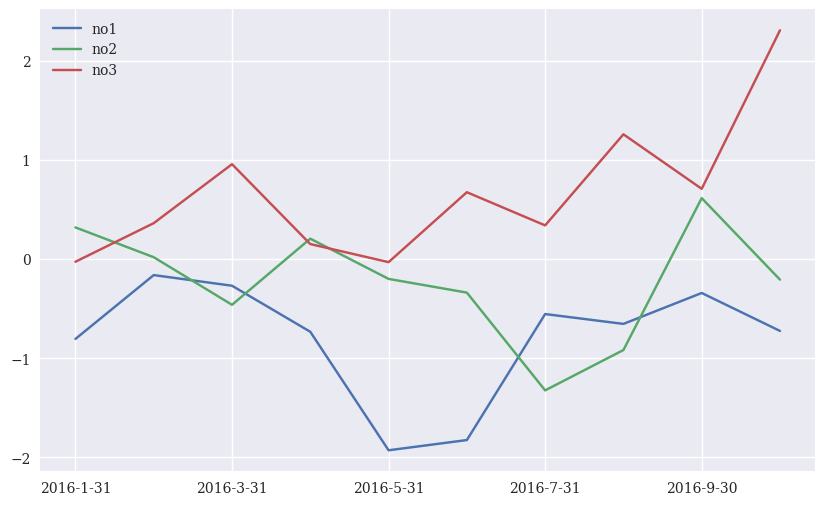

In [142]:
df.plot(figsize=(10, 6));

<p style="font-family: monospace;">Line plot from pandas DataFrame.

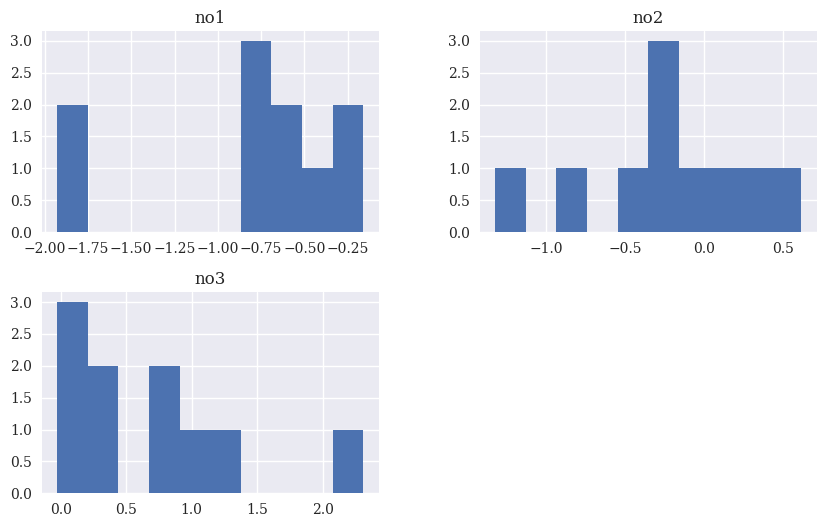

In [143]:
df.hist(figsize=(10, 6));

<p style="font-family: monospace;">Histograms from pandas DataFrame.

### Input-Output Operations

Another strength of pandas is the exporting and importing of data to and from diverse data storage formats. Consider the case of comma separated value (CSV) files.

In [144]:
df.to_csv('data.csv')  # exports to CSV file

Let us have a look at the just saved file with basic Python functionality.

In [145]:
with open('data.csv') as f:  # open file
    for l in f.readlines():  # iterate over all lines
        print(l, end='')  # print line

,no1,no2,no3
2016-1-31,-0.8044583035248052,0.3209315470898572,-0.025482880472072197
2016-2-28,-0.16013447509799084,0.020134874302836836,0.36399167381523484
2016-3-31,-0.26757177678888755,-0.4598482010579321,0.9590271758917921
2016-4-30,-0.7322393029842287,0.20743310593008457,0.15291156544935103
2016-5-31,-1.9283091368170626,-0.1985270554299729,-0.029465774923291332
2016-6-30,-1.825116242782081,-0.3369490440157358,0.6762266000356949
2016-7-31,-0.5533209663746157,-1.3236963728130973,0.3413911468241541
2016-8-31,-0.6528026643843926,-0.9165042724715742,1.2607786860286032
2016-9-30,-0.3406846543180292,0.6166567928863607,0.7106048210003029
2016-10-31,-0.723832065202327,-0.20628417055270565,2.310688189060956


Reading data from such files is also straightforward.

In [146]:
from_csv = pd.read_csv('data.csv',  # filename
                      index_col=0,  # index column
                      parse_dates=True)  # date index
from_csv.head()

,no1,no2,no3
2016-01-31,-0.804458,0.320932,-0.025483
2016-02-28,-0.160134,0.020135,0.363992
2016-03-31,-0.267572,-0.459848,0.959027
2016-04-30,-0.732239,0.207433,0.152912
2016-05-31,-1.928309,-0.198527,-0.029466


However, in general you would store ``DataFrame`` objects on disk in more efficient binary formats like HDF5 (see http://hdfgroup.org). pandas in this case wraps the functionality of the PyTables library (see http://pytables.org). The constructor function to be used is ``HDFStore()``.

In [147]:
h5 = pd.HDFStore('data.h5', 'w')  # open for writing
h5['df'] = df  # write object to database
h5

<class 'pandas.io.pytables.HDFStore'>
File path: data.h5

Data retrieval is as simple as writing.

In [148]:
from_h5 = h5['df']  # reading from database
h5.close()  # closing the database
from_h5.tail()

,no1,no2,no3
2016-6-30,-1.825116,-0.336949,0.676227
2016-7-31,-0.553321,-1.323696,0.341391
2016-8-31,-0.652803,-0.916504,1.260779
2016-9-30,-0.340685,0.616657,0.710605
2016-10-31,-0.723832,-0.206284,2.310688


In [149]:
!rm data.csv data.h5 # remove the objects from disk

### Financial Analytics Examples

When it comes to financial data, there are useful data retrieval functions available that wrap both the Yahoo! Finance and Google Finance financial data APIs. The following code reads historical daily data for the S&P 500 index and the VIX volatility index.  

In [150]:
# url = 'https://hilpisch.com/vola_eikon_eod_data.csv'
url = 'data/vola_eikon_eod_data.csv'

In [151]:
spx = pd.DataFrame(pd.read_csv(url, index_col=0, parse_dates=True)['.SPX'])

In [152]:
spx.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2670 entries, 2010-01-04 to 2020-10-23
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   .SPX    2670 non-null   float64
dtypes: float64(1)
memory usage: 41.7 KB


In [153]:
vix = pd.DataFrame(pd.read_csv(url, index_col=0, parse_dates=True)['.VIX'])

In [154]:
vix.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2670 entries, 2010-01-04 to 2020-10-23
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   .VIX    2670 non-null   float64
dtypes: float64(1)
memory usage: 41.7 KB


In [155]:
vix.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2670 entries, 2010-01-04 to 2020-10-23
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   .VIX    2670 non-null   float64
dtypes: float64(1)
memory usage: 41.7 KB


Let us combine the respective ``Close`` columns into a single ``DataFrame`` object. Muliple ways are possible to accomplish this goal. 

In [156]:
## construction via join
spxvix = pd.DataFrame(spx).join(vix)
spxvix.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2670 entries, 2010-01-04 to 2020-10-23
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   .SPX    2670 non-null   float64
 1   .VIX    2670 non-null   float64
dtypes: float64(2)
memory usage: 62.6 KB


In [157]:
## construction via merge
spxvix = pd.merge(spx, vix,
                  left_index=True,  # merge on left index
                  right_index=True,  # merge on right index
                )
spxvix.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2670 entries, 2010-01-04 to 2020-10-23
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   .SPX    2670 non-null   float64
 1   .VIX    2670 non-null   float64
dtypes: float64(2)
memory usage: 62.6 KB


In a case like this, the approach via `dictionary` objects might be the best and most intuitive way.

In [158]:
## construction via dictionary object
spxvix = pd.DataFrame({'SPX': spx.values.flatten(),
                       'VIX': vix.values.flatten()},
                       index=spx.index)
spxvix.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2670 entries, 2010-01-04 to 2020-10-23
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SPX     2670 non-null   float64
 1   VIX     2670 non-null   float64
dtypes: float64(2)
memory usage: 62.6 KB


Having available the merged data in a single object makes visual analysis straightforward (see the following figure).

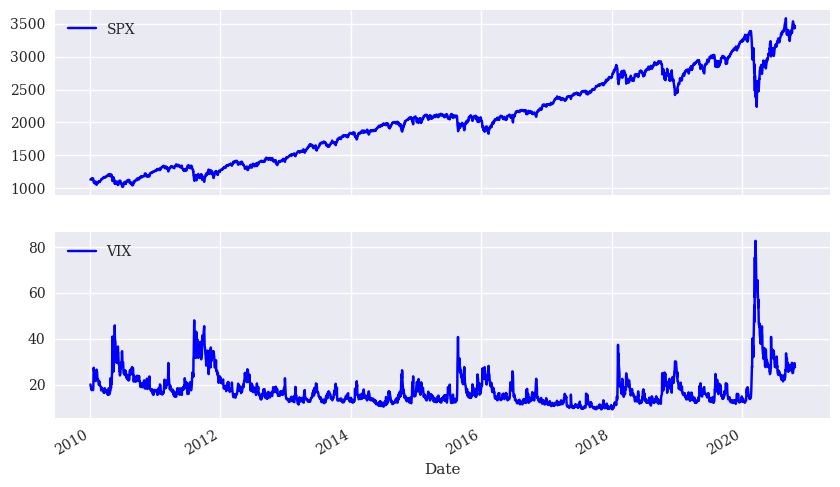

In [159]:
spxvix.plot(figsize=(10, 6), subplots=True, color='b');

<p style="font-family: monospace;">Historical closing data for S&P 500 stock index and VIX volatility index.

pandas also allows vectorized operations on whole ``DataFrame`` objects. The following code calculates the log returns over the two columns of the ``spxvix`` object simulateneously in vectorized fashion. The ``shift()`` method shifts the data set by the number of index values as provided (in this particular by one trading day). 

In [160]:
rets = np.log(spxvix / spxvix.shift(1))
rets.head()

,SPX,VIX
Date,,
2010-01-04,NaN,NaN
2010-01-05,0.003111,-0.035038
2010-01-06,0.000545,-0.009868
2010-01-07,0.003993,-0.005233
2010-01-08,0.002878,-0.050024


There is one row of log returns missing at the very beginning. This row can be deleted via the ``dropna()`` method.

In [161]:
rets = rets.dropna()
rets.head()

,SPX,VIX
Date,,
2010-01-05,0.003111,-0.035038
2010-01-06,0.000545,-0.009868
2010-01-07,0.003993,-0.005233
2010-01-08,0.002878,-0.050024
2010-01-11,0.001745,-0.032514


Consider the plot in the following figure showing the VIX log returns against the SPX log returns in a scatter plot with a linear regression. It illustrates a strong negative correlation between the two indexes. This is a central result that is replicated in the chapter about the EURO STOXX 50 stock index and the VSTOXX volatility index, respectively.

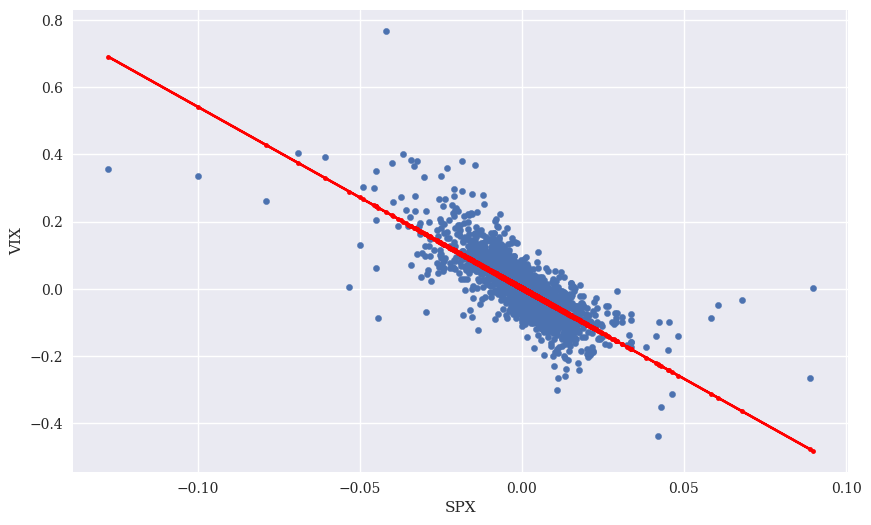

In [162]:
rets.plot(kind='scatter', x='SPX', y='VIX',
              style='.', figsize=(10, 6));
rg = np.polyfit(rets['SPX'], rets['VIX'], 1)
plt.plot(rets['SPX'], np.polyval(rg, rets['SPX']), 'r.-');

<p style="font-family: monospace;">Daily log returns for S&P 500 stock index and VIX volatility index and regression line.

Having financial time series data stored in a pandas ``DataFrame`` object makes the calculation of typical statistics straightforward.

In [163]:
ret = rets.mean() * 252  # annualized return
ret

SPX    0.105555
VIX    0.030050
dtype: float64

In [164]:
vol = rets.std() * math.sqrt(252)  # annualized volatility
vol

SPX    0.176931
VIX    1.261327
dtype: float64

In [165]:
(ret - 0.01) / vol  # Sharpe ratio with rf = 0.01

SPX    0.540072
VIX    0.015896
dtype: float64

The *maximum drawdown*, which we only calculate for the S&P 500 index, is a bit more involved. For its calculation, we use the ``cummax()`` method which records the running, historical maximum of the time series up to a certain date. Consider the plot in the following figure which shows the S&P 500 index and the running maximum.

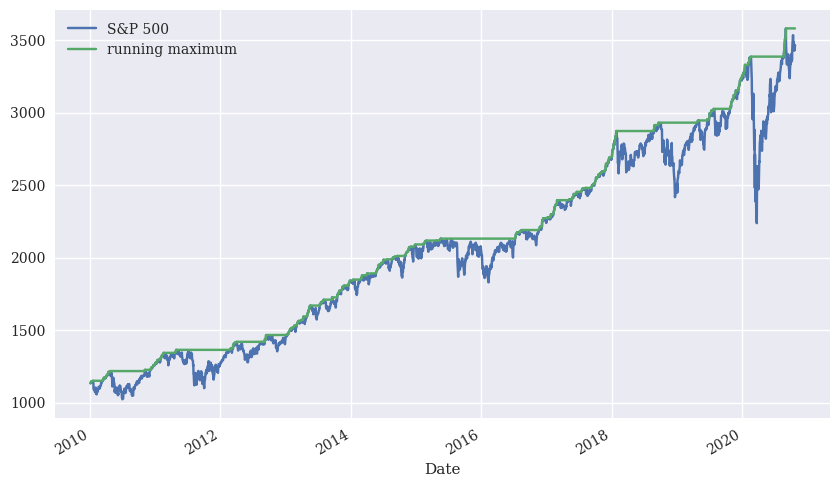

In [166]:
plt.figure(figsize=(10, 6));
spxvix['SPX'].plot(label='S&P 500');
spxvix['SPX'].cummax().plot(label='running maximum');
plt.legend(loc=0);

<p style="font-family: monospace;">S&P 500 stock index and running maximum value.

The maximum drawdown is the largest difference between the running maximum and the current index level &mdash; in our particular case it is 1,148.

In [167]:
adrawdown = spxvix['SPX'].cummax() - spxvix['SPX']
adrawdown.max()

1148.75

The relative maximum drawdown might sometimes be a bit more meaningful. It is here a drawdown of about 34%.

In [168]:
rdrawdown = (spxvix['SPX'].cummax() - spxvix['SPX']) / spxvix['SPX'].cummax() 
rdrawdown.max()

0.3392495902426059

The longest drawdown period is calculated as follows. The code below selects all those data points where the drawdown is zero. It then calculates the difference between two consecutive index values (i.e. trading dates) for which the drawdown is zero and takes the maxmimum value. Given the data set we are analyzing, the longest drawdown period is 417 days.

In [169]:
temp = adrawdown[adrawdown == 0]
periods_spx = (temp.index[1:].to_pydatetime()
             - temp.index[:-1].to_pydatetime())
periods_spx[50:60]  # some selected data points

array([datetime.timedelta(days=1), datetime.timedelta(days=1),
       datetime.timedelta(days=1), datetime.timedelta(days=301),
       datetime.timedelta(days=3), datetime.timedelta(days=1),
       datetime.timedelta(days=2), datetime.timedelta(days=12),
       datetime.timedelta(days=2), datetime.timedelta(days=1)],
      dtype=object)

In [170]:
max(periods_spx)

datetime.timedelta(days=417)

See Appendix C of Hilpisch (2018) for the handling of date-time information with Python, NumPy and pandas.

## Conclusions

This chapter introduces basic data types and structures as well as certain Python idioms needed for analyses in later chapters of the book. In addition, NumPy and the ``ndarray`` class are introduced which allow the efficient handling of and operating on (numerical) data stored as arrays. Some basic visualization techniques using the matplotlib library are also introduced. However, working with pandas and its powerful ``DataFrame`` class for tabular and time series data makes plotting a bit more convenient &mdash; only a single method call is needed in general. Using pandas and the capabilities of the ``DataFrame`` class, the chapter also illustrates by the means of some basic financial examples how to implement typical interactive financial analytics tasks.  